# TS Lab 1

Requirements: 

In [14]:
# If needed:
# !pip -q install numpy pandas matplotlib statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Dataset: small + interpretable
We’ll use a synthetic dataset so that we can see the components clearly.

Create a synthetic time series with components:

In [15]:
np.random.seed(7)

n = 500                      # 120 months = 10 years
t = np.arange(n)
trend = 0.05 * t
seasonality = 2.0 * np.sin(2 * np.pi * t / 12)   # yearly seasonality (period 12)
noise = np.random.normal(0, 0.8, size=n)

y = 10 + trend + seasonality + noise

ts = pd.Series(y, index=pd.period_range("2015-01", periods=n, freq="M").to_timestamp())
ts.head()


2015-01-01    11.352421
2015-02-01    10.677250
2015-03-01    11.858307
2015-04-01    12.476013
2015-05-01    11.300912
Freq: MS, dtype: float64

Plot and visually identify components:

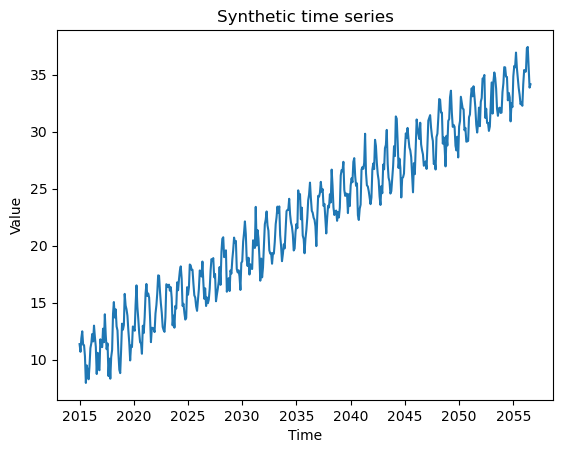

In [16]:
plt.figure()
plt.plot(ts)
plt.title("Synthetic time series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


### Questions:

- Where do you see trend?

- What suggests seasonality? What is the likely period?

- What part looks like noise?

- Create a series with no trend and no clear seasonality. 

### 2. Moving Average Smoothing

Implement moving average:

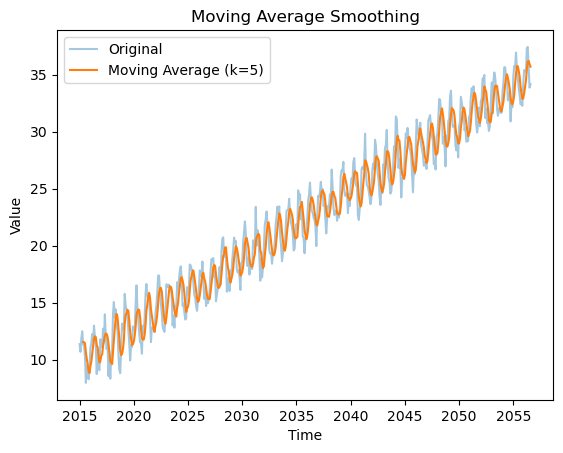

In [22]:
def moving_average(series, k):
    return series.rolling(window=k).mean()

k = 5
ma12 = moving_average(ts, k)

plt.figure()
plt.plot(ts, label="Original", alpha=0.4)
plt.plot(ma12, label=f"Moving Average (k={k})")
plt.title("Moving Average Smoothing")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


#### Exercises:

- Try k=3, k=6, k=12, k=24.

- Which k best reveals the trend? Which one hides seasonality too much?

#### Questions:

- What happens when the window becomes very large?

- Why do we lose some data at the beginning?

### 3. Exponential Smoothing

Implement exponential smoothing from scratch:

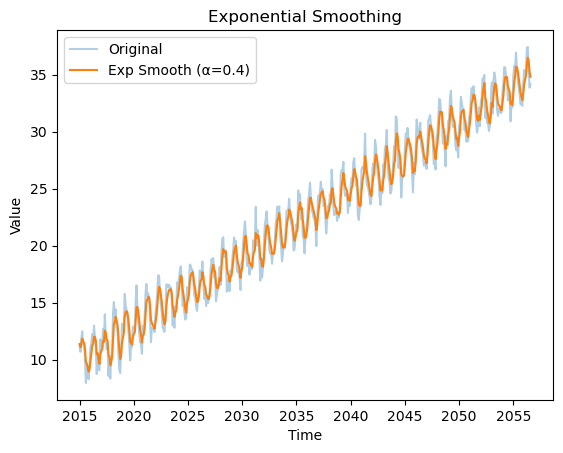

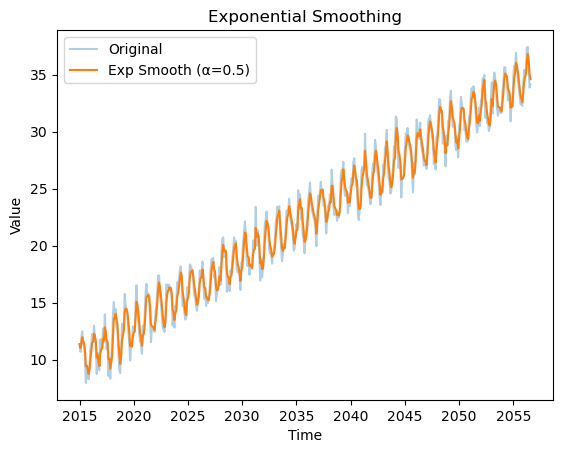

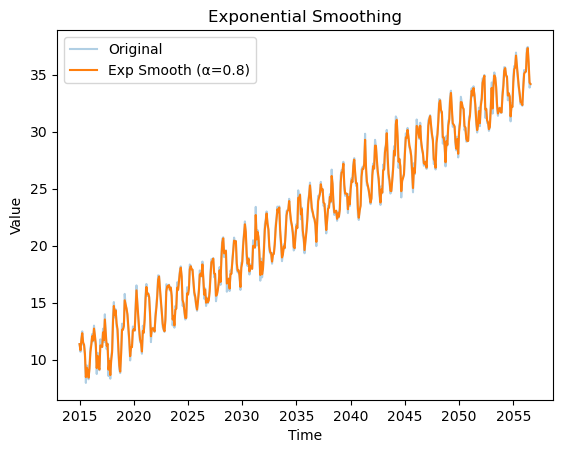

In [27]:
def exp_smooth(series, alpha):
    s = np.zeros(len(series))
    s[0] = series.iloc[0]
    for i in range(1, len(series)):
        s[i] = alpha * series.iloc[i] + (1 - alpha) * s[i-1]
    return pd.Series(s, index=series.index)

for alpha in [0.4, 0.5, 0.8]:
    sm = exp_smooth(ts, alpha)
    plt.figure()
    plt.plot(ts, alpha=0.35, label="Original")
    plt.plot(sm, label=f"Exp Smooth (α={alpha})")
    plt.title("Exponential Smoothing")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()


#### Questions:

- Why does larger α react faster?

- Why does smaller α look smoother?

### 4.Component patterns: “detect” trend/seasonality/noise

Detrend with moving average. Inspect residuals:

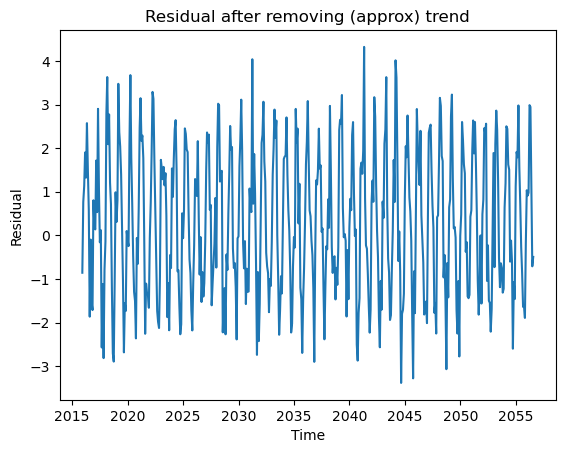

In [37]:
trend_est = moving_average(ts, 12)
residual = ts - trend_est

plt.figure()
plt.plot(residual)
plt.title("Residual after removing (approx) trend")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()


#### Questions:
Does the residual still show seasonality? What do you see?

### 5.An example of sudden changes
- Creates a time series with a sudden jump
- Shows lag of Moving Average (MA)
- Shows lag of Exponential Moving Average (EMA)
- Compares them clearly

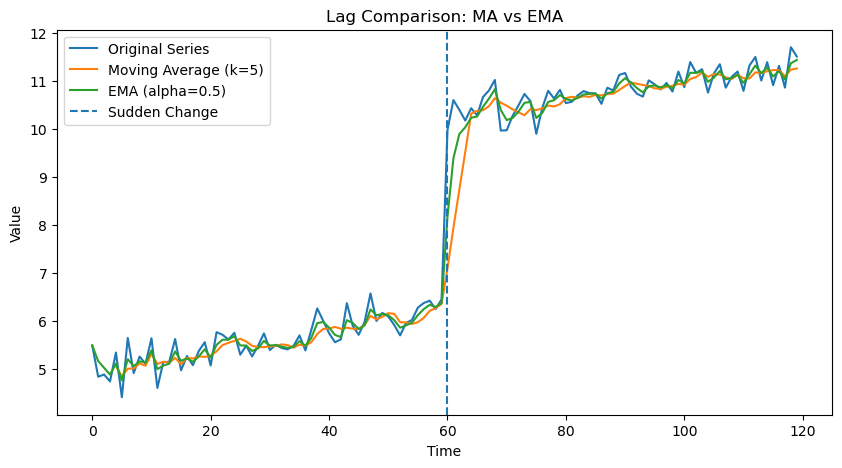

In [31]:

# -----------------------------
# 1) Create time series with sudden change
# -----------------------------
np.random.seed(1)

n = 120
t = np.arange(n)

# Base signal
y = 5 + 0.02*t + np.random.normal(0, 0.3, n)

#structural break
y[t >= 60] += 4


def moving_average(x, k):
    result = np.full_like(x, np.nan)
    for i in range(k-1, len(x)):
        result[i] = np.mean(x[i-k+1:i+1])
    return result


def ema(x, alpha):
    result = np.zeros_like(x)
    result[0] = x[0]
    for i in range(1, len(x)):
        result[i] = alpha*x[i] + (1-alpha)*result[i-1]
    return result


k = 5
alpha = 0.5

ma = moving_average(y, k)
ema_series = ema(y, alpha)

plt.figure(figsize=(10,5))
plt.plot(t, y, label="Original Series")
plt.plot(t, ma, label=f"Moving Average (k={k})")
plt.plot(t, ema_series, label=f"EMA (alpha={alpha})")
plt.axvline(60, linestyle="--", label="Sudden Change")
plt.title("Lag Comparison: MA vs EMA")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

Do MA and EMA behave differently for upward vs downward shocks? Implement your own code to examine their behaviour.